# 01 · How the tool thinks: one optimization problem, solved all at once

Before any aircraft physics, this tutorial teaches the *paradigm* every other part of the code follows. If you
understand this notebook, the 2,000-line sizing driver reads as a long but simple list of equations.

**What you will learn**
1. AeroSandbox's symbolic NumPy: write a physics function once, evaluate it with numbers *or* with optimization
   variables.
2. `asb.Opti`: variables, constraints, objective, IPOPT.
3. **Mass closure as an equality constraint** versus the classic fixed-point weight loop, on a toy VTOL, including
   what happens when no aircraft closes.
4. Why the code scales variables, normalizes constraints and replaces `max()` with smooth functions.
5. **Lagrange multipliers are sensitivities**: the solver tells you what each requirement costs.
6. Local optima and starting points: why the sizing has a multistart strategy.

**Run time:** about a minute.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

import aerosandbox as asb
import aerosandbox.numpy as np

## 1. Write the physics once

`aerosandbox.numpy` mirrors NumPy, but when an argument is a CasADi symbol it builds an expression graph instead of
computing a number. So one function serves analysis (numbers in, numbers out) and optimization (variables in,
differentiable expressions out). This is why the code style guide says "use `aerosandbox.numpy` for anything that
may receive symbolic values; never call `float()` on it; never branch on it with `if`".

In [2]:
def hover_power_W(mass_kg, area_disk_m2, figure_of_merit=0.7, density_kg_m3=1.225, g=9.80665):
    # Ideal momentum theory: P = T^1.5 / sqrt(2 rho A), divided by the figure of merit.
    thrust_N = mass_kg * g
    return thrust_N**1.5 / np.sqrt(2 * density_kg_m3 * area_disk_m2) / figure_of_merit

print("numbers in  :", hover_power_W(2000.0, 20.0))         # a float
opti = asb.Opti()
area = opti.variable(init_guess=20.0)
print("symbol in   :", type(hover_power_W(2000.0, area)))   # a CasADi expression graph

numbers in  : 560570.0966854955
symbol in   : <class 'casadi.casadi.MX'>


The same holds for every component in `src/aircraft_closure`: `Motor.evaluate(speed, torque, voltage)` returns
numbers when you pass numbers and expressions when the sizing passes variables. That is what lets the components be
unit-tested in isolation and then dropped unchanged into the big problem.

## 2. A toy VTOL, sized the classic way: the weight loop

A battery-electric VTOL carrying 400 kg: structure is a fraction of take-off mass, motors scale with hover power,
rotors with disk area, the battery with the energy for 2 minutes of hover plus a 50 km cruise. Every part depends on
the take-off mass, which is the sum of the parts. The classic answer is to **iterate**:

In [3]:
g = 9.80665

def parts_kg(mass_takeoff_kg, area_disk_m2, range_m=50e3, payload_kg=400.0):
    # Every part as a function of the current take-off mass guess (works with numbers or symbols).
    p_hover_W = hover_power_W(mass_takeoff_kg, area_disk_m2)
    p_cruise_W = mass_takeoff_kg * g * 50.0 / 12.0 / 0.8          # 50 m/s, L/D 12, propulsive efficiency 0.8
    energy_J = p_hover_W * 120 + p_cruise_W * range_m / 50.0
    return dict(payload=payload_kg,
                structure=0.30 * mass_takeoff_kg,
                motors=p_hover_W / 5000.0,                             # 5 kW/kg
                rotors=4.0 * area_disk_m2,                             # 4 kg per m2 of disk
                battery=energy_J / (180 * 3600.0) / 0.8)               # 180 Wh/kg, 80 % usable

def weight_loop(area_disk_m2, range_m=50e3, guess_kg=1000.0, iterations=60):
    history = [guess_kg]
    for _ in range(iterations):
        history.append(sum(parts_kg(history[-1], area_disk_m2, range_m).values()))
        if history[-1] > 1e9:          # runaway: stop before the numbers overflow
            break
    return history

history = weight_loop(10.0)
print(f"take-off mass {history[-1]:.2f} kg after {len(history) - 1} passes of the loop; "
      f"change on the last pass {history[-1] - history[-2]:.1e} kg")

take-off mass 904.50 kg after 60 passes of the loop; change on the last pass 0.0e+00 kg


That works for *one* design (disk area fixed at 10 m²). To find the best disk area you need an outer optimizer that
calls the loop many times, and differentiates through it by finite differences. And the loop hides a failure mode:

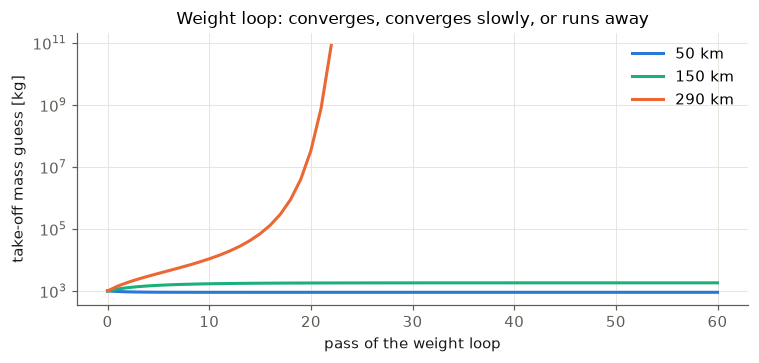

290 km: 8.21e+10 kg after 22 passes, and still growing


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for range_km, color in ((50, blue), (150, aqua), (290, orange)):
    h = weight_loop(10.0, range_km * 1e3)
    ax.plot(h, color=color, lw=2, label=f"{range_km} km")
ax.set(yscale="log", xlabel="pass of the weight loop", ylabel="take-off mass guess [kg]",
       title="Weight loop: converges, converges slowly, or runs away")
ax.legend(); plt.tight_layout(); plt.show()
runaway = weight_loop(10.0, 290e3)
print(f"290 km: {runaway[-1]:.3g} kg after {len(runaway) - 1} passes, and still growing")

At 290 km no aircraft closes: every kilogram added needs more than a kilogram of battery and motor to carry it (the
"snowball"). The loop just runs away, and slowly converging cases look similar for a while.

## 3. The same toy, the way size_halo does it

Make take-off mass a **variable**, write closure as an **equality constraint**, and let IPOPT solve closure and the
design choice together:

In [5]:
def size_all_at_once(range_m=50e3, payload_kg=400.0, verbose=False):
    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1000.0, scale=1000.0, lower_bound=100.0)
    area_disk_m2 = opti.variable(init_guess=10.0, scale=10.0, lower_bound=1.0, upper_bound=60.0)
    parts = parts_kg(mass_takeoff_kg, area_disk_m2, range_m, payload_kg)
    closure = opti.subject_to(mass_takeoff_kg / sum(parts.values()) == 1)   # normalized, as in halo_sizing.py:1300
    opti.minimize(mass_takeoff_kg / 1000.0)                                     # objective of order one
    solution = opti.solve(verbose=verbose)
    return opti, solution, mass_takeoff_kg, area_disk_m2, parts, closure

opti, sol, m, A, parts, closure = size_all_at_once()
print(f"optimum: take-off {sol.value(m):.2f} kg with a {sol.value(A):.2f} m2 disk, "
      f"in {sol.stats()['iter_count']} IPOPT iterations")
for name, kg in parts.items():
    print(f"   {name:<10}{sol.value(kg):8.1f} kg")

# Check: the loop at the optimal disk area gives the same mass, and no other disk area does better.
check("the weight loop at the optimal disk area reproduces the closed mass",
      abs(weight_loop(sol.value(A))[-1] - sol.value(m)) < 1e-3)
areas = np.linspace(4, 40, 37)
masses = [weight_loop(a_m2)[-1] for a_m2 in areas]
check("a brute-force sweep of the loop finds no lighter design", min(masses) >= sol.value(m) - 1e-3)

optimum: take-off 902.10 kg with a 11.88 m2 disk, in 5 IPOPT iterations
   payload      400.0 kg
   structure    270.6 kg
   motors        44.1 kg
   rotors        47.5 kg
   battery      139.9 kg
PASS  the weight loop at the optimal disk area reproduces the closed mass
PASS  a brute-force sweep of the loop finds no lighter design


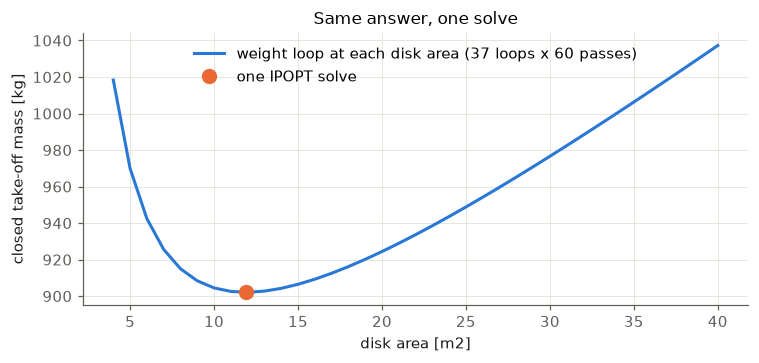

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(areas, masses, color=blue, lw=2, label="weight loop at each disk area (37 loops x 60 passes)")
ax.plot(sol.value(A), sol.value(m), "o", color=orange, ms=9, label="one IPOPT solve")
ax.set(xlabel="disk area [m2]", ylabel="closed take-off mass [kg]", title="Same answer, one solve")
ax.legend(); plt.tight_layout(); plt.show()

And when no aircraft closes, the solver *says so* instead of running away:

In [7]:
try:
    size_all_at_once(range_m=290e3)
    print("solved?!")
except RuntimeError as error:
    import re
    print("IPOPT return status:", re.search(r"return_status is '(\w+)'", str(error)).group(1))
    print("-> the 290 km requirement has no closed aircraft: an infeasibility, reported as one.")

IPOPT return status: Infeasible_Problem_Detected
-> the 290 km requirement has no closed aircraft: an infeasibility, reported as one.


Three things to take from this:

- **Closure is just another equation.** In `examples/halo_sizing.py` it is literally
  `mass_takeoff_kg / total.mass == 1`, one line among the power balances, the state-of-charge chain and about 900
  other constraints. IPOPT satisfies all of them at the same time. Nothing iterates to a fixed point.
- **Exact derivatives through everything.** CasADi differentiates the whole expression graph (automatic
  differentiation), so the optimizer sees how take-off mass responds to every design variable through every
  discipline at once. A nested loop with finite differences is slower and noisier, and gets worse as the problem
  grows: the Halo problem has 140 variables.
- **Coupled problems that do not close show up as infeasibility**, which is something you can report and diagnose.

In MDO vocabulary this is an **all-at-once / simultaneous** formulation (sometimes called SAND, simultaneous
analysis and design): the coupling variables (take-off mass, bus current, rotor speed, induced velocity...) are
optimization variables and the coupling equations are constraints. The alternatives are MDF (an inner solver
converges the disciplines for each optimizer step; the classic weight loop is a tiny MDF) and IDF (copies of
coupling variables with consistency constraints). All-at-once is the cheapest per optimizer step and gives exact
gradients, at the price of a large NLP that must be well scaled and smooth. The next sections are that price.

## 4. The price: scaling and smoothness

IPOPT is a Newton-type interior-point method. It converges fast when variables and residuals are of order one and
when every function is twice differentiable. The codebase does three things everywhere because of that.

**(a) Variable scaling.** Every `opti.variable(...)` in the sizing carries a `scale=`: take-off mass `scale=1000`,
battery energy `1e8`, rotor speed `100`. IPOPT then works on numbers near one.

**(b) Normalized constraints.** Equalities are written as ratios (`MTOM / Σ = 1`, `lift / weight == cos γ`, powers
divided by the installed motor rating), and every margin is divided by its limit. A 10 kW residual and a 0.001 m
residual then mean the same thing to the solver.

**(c) Smooth replacements for kinks.** `max()`, `abs()` and step functions have no derivative at the kink, and
Newton steps chatter around it. The code uses `np.softmax(a, b, softness=s)` (a smooth maximum that overestimates the
true maximum by at most `s · ln 2`) for things like "battery mass is the larger of energy-sized and power-sized",
`softplus` for the gear-stage count, and `sqrt(P² + ε²)` for |P|. Each softness is chosen small against the
quantity and stated next to it.

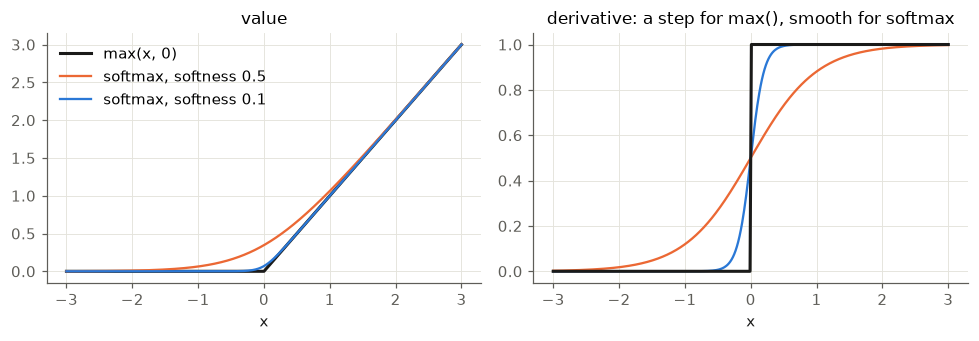

PASS  softmax overestimates max by at most softness x ln 2


In [8]:
from aerosandbox.numpy import softmax
x = np.linspace(-3, 3, 601)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(x, np.maximum(x, 0), color=ink, lw=2, label="max(x, 0)")
for s, color in ((0.5, orange), (0.1, blue)):
    axes[0].plot(x, softmax(x, 0 * x, softness=s), color=color, lw=1.5, label=f"softmax, softness {s}")
    axes[1].plot(x, np.gradient(softmax(x, 0 * x, softness=s), x), color=color, lw=1.5)
axes[1].plot(x, np.gradient(np.maximum(x, 0), x), color=ink, lw=2)
axes[0].set(title="value", xlabel="x"); axes[1].set(title="derivative: a step for max(), smooth for softmax", xlabel="x")
axes[0].legend(); plt.tight_layout(); plt.show()
check("softmax overestimates max by at most softness x ln 2",
      np.max(softmax(x, 0 * x, softness=0.1) - np.maximum(x, 0)) <= 0.1 * np.log(2) + 1e-12)

In [9]:
# What scaling buys, on the toy: the same problem with and without variable scales.
def toy(scaled):
    opti = asb.Opti()
    m = opti.variable(init_guess=1000.0, scale=1000.0 if scaled else 1.0, lower_bound=100.0)
    A = opti.variable(init_guess=10.0, scale=10.0 if scaled else 1.0, lower_bound=1.0, upper_bound=60.0)
    opti.subject_to(m / sum(parts_kg(m, A).values()) == 1 if scaled else m - sum(parts_kg(m, A).values()) == 0)
    opti.minimize(m / 1000 if scaled else m)
    return opti.solve(verbose=False).stats()["iter_count"]

print("IPOPT iterations, scaled and normalized:", toy(True))
print("IPOPT iterations, raw units           :", toy(False))

IPOPT iterations, scaled and normalized: 5
IPOPT iterations, raw units           : 10


On a two-variable toy the difference is small (IPOPT also scales internally). On the 140-variable, 960-constraint
Halo problem, the design log records solves that failed or stalled until a term was normalized or a kink smoothed;
for example the B-spline engine part-power curve stalled IPOPT for 3,000 iterations and was replaced by a cubic
(`docs/decisions/014`).

## 5. Lagrange multipliers: the price of each requirement

At an optimum, each active constraint has a **Lagrange multiplier** λ: how much the objective would improve if that
constraint were relaxed by one unit. AeroSandbox returns it from `opti.subject_to(...)`. Because every margin in the
sizing is normalized and the objective is take-off mass in tonnes, λ reads directly as *tonnes of take-off mass per
unit of margin*: a λ of 1.2 means tightening that requirement by 1 % costs about 12 kg.

Check it on the toy: give it a maximum disk area (a footprint limit), read λ, and compare with re-solving.

In [10]:
def toy_with_footprint(area_max_m2):
    opti = asb.Opti()
    m = opti.variable(init_guess=1000.0, scale=1000.0, lower_bound=100.0)
    A = opti.variable(init_guess=5.0, scale=10.0, lower_bound=1.0)
    opti.subject_to(m / sum(parts_kg(m, A).values()) == 1)
    footprint = opti.subject_to((area_max_m2 - A) / area_max_m2 >= 0)      # a normalized margin, as in core/margins.py
    opti.minimize(m / 1000)
    s = opti.solve(verbose=False)
    return s.value(m), s.value(footprint)

mass_kg, lam = toy_with_footprint(8.0)
mass_tight_kg, _ = toy_with_footprint(8.0 * (1 - 0.01))        # require 1 % more margin = 1 % smaller footprint
print(f"lambda = {lam:.4f} t per unit margin -> predicts +{1000 * lam * 0.01:.2f} kg for 1 % tighter")
print(f"re-solving with a 1 % smaller footprint: +{mass_tight_kg - mass_kg:.2f} kg")
check("the multiplier predicts the re-solved change within 5 %",
      abs(1000 * lam * 0.01 - (mass_tight_kg - mass_kg)) < 0.05 * (mass_tight_kg - mass_kg))

lambda = 0.0667 t per unit margin -> predicts +0.67 kg for 1 % tighter
re-solving with a 1 % smaller footprint: +0.68 kg
PASS  the multiplier predicts the re-solved change within 5 %


Tutorial 10 reads these multipliers off the full Halo solve: the rotor-radius limit and the engine-out battery
voltage turn out to be the two most expensive requirements. That is the quantitative version of "what sizes the
aircraft".

The same idea gives the **weight growth factor**, dMTOM/dpayload: how many kilograms of take-off mass one more
kilogram of payload costs once everything resizes. On the toy:

In [11]:
_, s1, m1, *_ = size_all_at_once(payload_kg=400.0)
_, s2, m2, *_ = size_all_at_once(payload_kg=401.0)
print(f"growth factor dMTOM/dpayload = {s2.value(m2) - s1.value(m1):.2f} kg per kg")

growth factor dMTOM/dpayload = 2.26 kg per kg


The Halo's growth factor is about 3 (`docs/RESULTS.md`): every kilogram added anywhere costs about three at
take-off. That is why the empty-weight uncertainty in tutorial 07 matters so much.

## 6. Local optima and starting points

IPOPT finds a *local* optimum near its starting point, and it can fail to converge from a poor one. A toy with two
valleys:

In [12]:
def two_valleys(x0):
    opti = asb.Opti()
    x = opti.variable(init_guess=x0)
    opti.minimize((x**2 - 4)**2 + 0.5 * x)
    return opti.solve(verbose=False).value(x)

for x0 in (-3.0, -0.5, 0.5, 3.0):
    print(f"start {x0:+.1f} -> x* = {two_valleys(x0):+.4f}")

start -3.0 -> x* = -2.0154
start -0.5 -> x* = -2.0154
start +0.5 -> x* = +1.9842
start +3.0 -> x* = +1.9842


The Halo problem behaves the same way in places: the gear-stage staircase has one local optimum per stage count,
and IPOPT can fail from a generic guess once the thermal model and the equivalent-circuit battery are on. The answer
in `solve_halo_sizing_multistart` (tutorial 10) is an explicit, finite, ordered list of starting points, each an
independent complete solve, often of a simpler *precursor* problem first. It is not a hidden convergence loop: no
quantity is iterated to a fixed point, and the record says which start succeeded. `select="best"` runs them all and
reports the spread between local optima.

## Why it is built this way

- **One NLP instead of a loop:** exact gradients through every discipline, the true coupled optimum, binding
  constraints by name, multipliers as sensitivities, and infeasibility reported rather than divergence.
- **AeroSandbox rather than OpenMDAO:** this project chose to compose AeroSandbox (symbolic NumPy, `Opti`, models)
  and keep its own layer thin. OpenMDAO would give a component/group framework with semi-analytic derivatives and
  MDF/IDF drivers, at the cost of more structure per component. The project's own topology layer is described as
  "like an OpenMDAO Group (`add`, `connect`) but much lighter", and it deliberately does not own solving
  (`docs/ARCHITECTURE.md`). (The design log does not record a head-to-head comparison; this is the stated philosophy.)
- **Components never solve.** Hidden inner solvers would break exact derivatives and hide couplings. If a component
  needs an implicit relation (induced velocity, battery current), the *caller* adds a variable and an equality.

## What it can't do

- **Global optimality** is not guaranteed; only local optima, made robust by starting points.
- **Integers** (number of motor units, gear stages, battery strings) are not native to an NLP. The code relaxes them,
  rounds, and re-solves (tutorial 04), or enumerates discrete options (bus voltage).
- **Non-smooth physics** (stall, table look-ups, switching logic) must be smoothed or kept out of the loop. That is
  one reason there is no blade stall in the rotor model (tutorial 03).
- **Black-box codes** (CFD, FE, a supplier engine deck as an executable) cannot go inside: everything must be an
  expression CasADi can differentiate. They enter as fitted surrogates, maps or calibration factors.

## What's next

- Surrogates of higher-fidelity tools (fitted polynomials, or AeroSandbox-compatible fits) are the planned route for
  bringing blade-element rotor maps and drag data into the loop (`docs/FIDELITY_ROADMAP.md`).
- Discrete choices (catalogue machines, stage counts, bus voltages) by enumeration around the NLP, as already done for
  bus voltage (`enumerate_bus_voltage`).

## Check yourself

<details><summary>1. Why is "mass closure as an equality" not just a cosmetic difference from a weight loop?</summary>

Because the closure is then solved simultaneously with the design choice and every other coupling, with exact
derivatives. A loop converges one fixed design; optimizing over designs needs an outer loop and finite differences.
And when no design closes, the NLP reports infeasibility while the loop diverges or crawls.
</details>

<details><summary>2. A margin has λ = 1.17 (objective: take-off mass in tonnes). What does that mean?</summary>

Requiring 1 % more margin on that constraint costs about 1000 × 1.17 × 0.01 ≈ 12 kg of take-off mass, and relaxing
it by 1 % saves about as much (to first order).
</details>

<details><summary>3. Why softmax rather than max for "the battery is sized by the larger of energy or power"?</summary>

max() has a kink where the two arguments cross, exactly where an optimum tends to sit (the two sizing criteria
balance). The kink breaks Newton steps. Softmax is smooth everywhere and overestimates by at most softness × ln 2,
which is chosen small (10 kg on a battery of hundreds of kg).
</details>

<details><summary>4. Is the multistart strategy a hidden fixed-point iteration?</summary>

No. Each candidate is an independent, complete solve of the same coupled problem from a different initial guess
(sometimes the solution of a simpler problem). Nothing is iterated toward consistency; the couplings all live
inside each solve.
</details>

In [13]:
check_summary()

4 of 4 checks passed
